# Maven Market - Join dữ liệu bán hàng với thời tiết và EDA cơ bản

Notebook này tạo bảng phân tích ở grain **observed `date + store_id`** cho Maven Market USA, sau đó join với dữ liệu thời tiết Open-Meteo ở cùng grain **`date + store_id`**.

Mục tiêu:

- Join các bảng Maven Market: transactions, products, stores, regions, calendar, returns, customers.
- Lọc USA stores vì file weather hiện có là `maven_us_open_meteo_daily_weather.csv` cho store-city tại Mỹ.
- Tạo target `net_revenue = gross_revenue - return_value` ở cấp store-day.
- Join weather theo `date + store_id`.
- Kiểm tra chất lượng join và phân tích dữ liệu cơ bản.

## 1. Import thư viện và khai báo đường dẫn

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
from IPython.display import Markdown, display
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 140)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")


def find_project_root(start=Path.cwd()):
    for path in [start, *start.parents]:
        if (path / "data" / "Maven Market Datasets").exists():
            return path
    raise FileNotFoundError("Không tìm thấy project root chứa data/Maven Market Datasets")


PROJECT_ROOT = find_project_root()
MAVEN_DIR = PROJECT_ROOT / "data" / "Maven Market Datasets"
WEATHER_PATH = PROJECT_ROOT / "data" / "weather" / "maven_us_open_meteo_daily_weather.csv"
OUTPUT_PATH = MAVEN_DIR / "processed" / "maven.csv"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("MAVEN_DIR:", MAVEN_DIR)
print("WEATHER_PATH exists:", WEATHER_PATH.exists())

PROJECT_ROOT: /Users/tnhatnguyendev2805/Documents/University/Data Science/Final Project
MAVEN_DIR: /Users/tnhatnguyendev2805/Documents/University/Data Science/Final Project/data/Maven Market Datasets
WEATHER_PATH exists: True


## 2. Đọc dữ liệu gốc

Các bảng Maven là star-schema đơn giản:

- `Transactions`: fact bán hàng theo dòng giao dịch.
- `Products`: giá bán, cost, brand.
- `Stores` + `Regions`: thông tin cửa hàng và địa lý.
- `Customers`: thông tin khách hàng, dùng để đếm khách/distinct customer ở aggregation.
- `Returns`: số lượng trả hàng.
- `Calendar`: date dimension.
- `Weather`: daily weather theo store-city của USA stores.

In [2]:
calendar_raw = pd.read_csv(MAVEN_DIR / "MavenMarket_Calendar.csv")
customers_raw = pd.read_csv(MAVEN_DIR / "MavenMarket_Customers.csv")
products_raw = pd.read_csv(MAVEN_DIR / "MavenMarket_Products.csv")
regions_raw = pd.read_csv(MAVEN_DIR / "MavenMarket_Regions.csv")
returns_raw = pd.read_csv(MAVEN_DIR / "MavenMarket_Returns_1997-1998.csv")
stores_raw = pd.read_csv(MAVEN_DIR / "MavenMarket_Stores.csv")
txn_1997_raw = pd.read_csv(MAVEN_DIR / "MavenMarket_Transactions_1997.csv")
txn_1998_raw = pd.read_csv(MAVEN_DIR / "MavenMarket_Transactions_1998.csv")
weather_raw = pd.read_csv(WEATHER_PATH)

raw_tables = {
    "calendar": calendar_raw,
    "customers": customers_raw,
    "products": products_raw,
    "regions": regions_raw,
    "returns": returns_raw,
    "stores": stores_raw,
    "transactions_1997": txn_1997_raw,
    "transactions_1998": txn_1998_raw,
    "weather": weather_raw,
}

schema_summary = pd.DataFrame([
    {"table": name, "rows": len(df), "columns": df.shape[1]}
    for name, df in raw_tables.items()
])
display(schema_summary)

display(txn_1997_raw.head())
display(weather_raw.head())

,table,rows,columns
0,calendar,730,1
1,customers,10281,20
2,products,1560,9
3,regions,109,3
4,returns,7087,4
5,stores,24,13
6,transactions_1997,86837,6
7,transactions_1998,182883,6
8,weather,9490,28


,transaction_date,stock_date,product_id,customer_id,store_id,quantity
0,1/1/1997,12/31/1996,869,3449,6,5
1,1/1/1997,12/31/1996,1472,3449,6,3
2,1/1/1997,12/28/1996,76,3449,6,4
3,1/1/1997,12/26/1996,320,3449,6,3
4,1/1/1997,12/25/1996,4,3449,6,4


,source_dataset,weather_location_id,date,store_id,store_name,store_city,store_state,location_name,weather_spatial_level,weather_code,temperature_max_c,temperature_min_c,temperature_mean_c,apparent_temperature_mean_c,precipitation_mm,rain_mm,snowfall_cm,wind_speed_max_kmh,wind_gusts_max_kmh,shortwave_radiation_mj_m2,latitude_requested,longitude_requested,latitude_open_meteo,longitude_open_meteo,elevation_m,timezone,utc_offset_seconds,weather_source
0,maven_market_us,maven_store_2,1997-01-01,2,Store 2,Bellingham,WA,"Bellingham, WA",store_city,61,10.1000,5.0000,7.2000,2.5000,21.3000,21.3000,0.0000,42.4000,104.4000,1.6600,48.7519,-122.4787,48.7522,-122.4366,23.0000,America/Los_Angeles,-25200,open_meteo_archive
1,maven_market_us,maven_store_2,1997-01-02,2,Store 2,Bellingham,WA,"Bellingham, WA",store_city,63,6.8000,4.4000,6.0000,2.5000,35.9000,35.9000,0.0000,24.5000,57.6000,0.6200,48.7519,-122.4787,48.7522,-122.4366,23.0000,America/Los_Angeles,-25200,open_meteo_archive
2,maven_market_us,maven_store_2,1997-01-03,2,Store 2,Bellingham,WA,"Bellingham, WA",store_city,61,5.3000,1.7000,3.3000,-0.0000,7.2000,7.2000,0.0000,13.6000,31.7000,3.9600,48.7519,-122.4787,48.7522,-122.4366,23.0000,America/Los_Angeles,-25200,open_meteo_archive
3,maven_market_us,maven_store_2,1997-01-04,2,Store 2,Bellingham,WA,"Bellingham, WA",store_city,51,4.9000,1.4000,2.7000,-0.8000,0.5000,0.5000,0.0000,15.6000,32.4000,3.2600,48.7519,-122.4787,48.7522,-122.4366,23.0000,America/Los_Angeles,-25200,open_meteo_archive
4,maven_market_us,maven_store_2,1997-01-05,2,Store 2,Bellingham,WA,"Bellingham, WA",store_city,3,4.5000,-0.9000,1.5000,-1.5000,0.0000,0.0000,0.0000,18.7000,36.0000,3.5400,48.7519,-122.4787,48.7522,-122.4366,23.0000,America/Los_Angeles,-25200,open_meteo_archive


## 3. Chuẩn hóa dimension tables

Ta chuẩn hóa date, tạo calendar features, làm sạch flag sản phẩm, và join `stores` với `regions`. Weather hiện chỉ có USA stores, nên phần phân tích chính sẽ lọc `store_country == "USA"`.

In [3]:
calendar = calendar_raw.copy()
calendar["date"] = pd.to_datetime(calendar["date"])
calendar["year"] = calendar["date"].dt.year
calendar["month"] = calendar["date"].dt.month
calendar["quarter"] = calendar["date"].dt.quarter
calendar["week_of_year"] = calendar["date"].dt.isocalendar().week.astype(int)
calendar["day_of_month"] = calendar["date"].dt.day
calendar["day_of_year"] = calendar["date"].dt.dayofyear
calendar["day_of_week"] = calendar["date"].dt.day_name()
calendar["day_of_week_num"] = calendar["date"].dt.dayofweek
calendar["is_weekend"] = calendar["day_of_week_num"].isin([5, 6]).astype("int8")
calendar["year_month"] = calendar["date"].dt.to_period("M").astype(str)

customers = customers_raw.copy()
customers["birthdate"] = pd.to_datetime(customers["birthdate"])
customers["acct_open_date"] = pd.to_datetime(customers["acct_open_date"])

products = products_raw.copy()
products["recyclable"] = products["recyclable"].fillna(0).astype("int8")
products["low_fat"] = products["low_fat"].fillna(0).astype("int8")

stores = stores_raw.merge(regions_raw, on="region_id", how="left", validate="many_to_one")
stores["first_opened_date"] = pd.to_datetime(stores["first_opened_date"])
stores["last_remodel_date"] = pd.to_datetime(stores["last_remodel_date"])
stores["grocery_sqft_ratio"] = stores["grocery_sqft"] / stores["total_sqft"]

usa_stores = stores.loc[stores["store_country"].eq("USA")].copy()
usa_store_ids = sorted(usa_stores["store_id"].unique().tolist())

print("USA stores:", len(usa_store_ids))
print("USA store ids:", usa_store_ids)
print("USA states:", sorted(usa_stores["store_state"].unique().tolist()))
display(usa_stores[["store_id", "store_name", "store_type", "store_city", "store_state", "store_country", "sales_region", "total_sqft", "grocery_sqft"]].sort_values("store_id"))

USA stores: 13
USA store ids: [2, 3, 6, 7, 11, 13, 14, 15, 16, 17, 22, 23, 24]
USA states: ['CA', 'OR', 'WA']


,store_id,store_name,store_type,store_city,store_state,store_country,sales_region,total_sqft,grocery_sqft
1,2,Store 2,Small Grocery,Bellingham,WA,USA,North West,28206,22271
2,3,Store 3,Supermarket,Bremerton,WA,USA,North West,39696,24390
5,6,Store 6,Gourmet Supermarket,Beverly Hills,CA,USA,South West,23688,15337
6,7,Store 7,Supermarket,Los Angeles,CA,USA,South West,23598,14210
10,11,Store 11,Supermarket,Portland,OR,USA,North West,20319,16232
12,13,Store 13,Deluxe Supermarket,Salem,OR,USA,North West,27694,18670
13,14,Store 14,Small Grocery,San Francisco,CA,USA,Central West,22478,15321
14,15,Store 15,Supermarket,Seattle,WA,USA,North West,21215,13305
15,16,Store 16,Supermarket,Spokane,WA,USA,North West,30268,22063
16,17,Store 17,Deluxe Supermarket,Tacoma,WA,USA,North West,33858,22123


## 4. Thiết kế join

Grain cuối cùng của bảng phân tích là **observed store-day**:

```text
date + store_id
```

Cách join:

1. Gộp transaction 1997 và 1998.
2. Lọc USA transactions vì weather file chỉ có USA stores.
3. Join transactions với products qua `product_id` để tính `gross_revenue = quantity * product_retail_price`.
4. Join stores/regions qua `store_id` để lấy địa lý và loại cửa hàng.
5. Join customers qua `customer_id` để lấy thông tin khách hàng, sau đó aggregate lên store-day.
6. Xử lý returns riêng: join returns với products để tính `return_value`, rồi aggregate lên store-day.
7. Outer join sales-store-day với returns-store-day theo `date + store_id` để không làm mất ngày chỉ có return.
8. Join calendar theo `date`.
9. Join weather theo **`date + store_id`** vì weather đã được tạo theo store-city của từng USA store.

Lý do không join weather chỉ theo `date`: cùng một ngày, CA/OR/WA có thời tiết khác nhau. Join theo `date + store_id` giữ đúng địa lý cửa hàng.

## 5. Gộp transactions và lọc USA

In [4]:
txn_1997 = txn_1997_raw.copy()
txn_1998 = txn_1998_raw.copy()
txn_1997["source_year_file"] = 1997
txn_1998["source_year_file"] = 1998

transactions_all = pd.concat([txn_1997, txn_1998], ignore_index=True)
transactions_all["transaction_date"] = pd.to_datetime(transactions_all["transaction_date"])
transactions_all["stock_date"] = pd.to_datetime(transactions_all["stock_date"])

transactions_us = transactions_all.loc[transactions_all["store_id"].isin(usa_store_ids)].copy()

transaction_scope = pd.DataFrame({
    "metric": [
        "all_transaction_rows",
        "usa_transaction_rows",
        "usa_row_share_pct",
        "usa_first_transaction_date",
        "usa_last_transaction_date",
        "usa_store_count",
    ],
    "value": [
        len(transactions_all),
        len(transactions_us),
        len(transactions_us) / len(transactions_all) * 100,
        transactions_us["transaction_date"].min(),
        transactions_us["transaction_date"].max(),
        transactions_us["store_id"].nunique(),
    ],
})

display(transaction_scope)
display(transactions_us.head())

,metric,value
0,all_transaction_rows,269720
1,usa_transaction_rows,180823
2,usa_row_share_pct,67.0410
3,usa_first_transaction_date,1997-01-01 00:00:00
4,usa_last_transaction_date,1998-12-30 00:00:00
5,usa_store_count,13


,transaction_date,stock_date,product_id,customer_id,store_id,quantity,source_year_file
0,1997-01-01,1996-12-31,869,3449,6,5,1997
1,1997-01-01,1996-12-31,1472,3449,6,3,1997
2,1997-01-01,1996-12-28,76,3449,6,4,1997
3,1997-01-01,1996-12-26,320,3449,6,3,1997
4,1997-01-01,1996-12-25,4,3449,6,4,1997


## 6. Join line items với product/store/customer và tính gross revenue

Đây là join ở cấp dòng giao dịch. Sau bước này mới aggregate lên store-day.

In [5]:
line_items_us = transactions_us.merge(products, on="product_id", how="left", validate="many_to_one")
line_items_us = line_items_us.merge(usa_stores, on="store_id", how="left", validate="many_to_one")
line_items_us = line_items_us.merge(customers, on="customer_id", how="left", validate="many_to_one")

line_items_us["gross_revenue"] = line_items_us["quantity"] * line_items_us["product_retail_price"]
line_items_us["gross_cost"] = line_items_us["quantity"] * line_items_us["product_cost"]
line_items_us["gross_profit"] = line_items_us["gross_revenue"] - line_items_us["gross_cost"]
line_items_us["gross_margin_pct_line"] = np.where(
    line_items_us["gross_revenue"].gt(0),
    line_items_us["gross_profit"] / line_items_us["gross_revenue"],
    np.nan,
)
line_items_us["customer_age"] = (line_items_us["transaction_date"] - line_items_us["birthdate"]).dt.days / 365.25
line_items_us["stock_lag_days"] = (line_items_us["transaction_date"] - line_items_us["stock_date"]).dt.days

line_item_join_quality = pd.DataFrame({
    "metric": [
        "rows",
        "missing_product_rows",
        "missing_store_rows",
        "missing_customer_rows",
        "negative_gross_revenue_rows",
        "zero_gross_revenue_rows",
    ],
    "value": [
        len(line_items_us),
        int(line_items_us["product_brand"].isna().sum()),
        int(line_items_us["store_name"].isna().sum()),
        int(line_items_us["first_name"].isna().sum()),
        int(line_items_us["gross_revenue"].lt(0).sum()),
        int(line_items_us["gross_revenue"].eq(0).sum()),
    ],
})

display(line_item_join_quality)
display(line_items_us.head())

,metric,value
0,rows,180823
1,missing_product_rows,0
2,missing_store_rows,0
3,missing_customer_rows,0
4,negative_gross_revenue_rows,0
5,zero_gross_revenue_rows,0


,transaction_date,stock_date,product_id,customer_id,store_id,quantity,source_year_file,product_brand,product_name,product_sku,product_retail_price,product_cost,product_weight,recyclable,low_fat,region_id,store_type,store_name,store_street_address,store_city,store_state,store_country,store_phone,first_opened_date,last_remodel_date,total_sqft,grocery_sqft,sales_district,sales_region,grocery_sqft_ratio,customer_acct_num,first_name,last_name,customer_address,customer_city,customer_state_province,customer_postal_code,customer_country,birthdate,marital_status,yearly_income,gender,total_children,num_children_at_home,education,acct_open_date,member_card,occupation,homeowner,gross_revenue,gross_cost,gross_profit,gross_margin_pct_line,customer_age,stock_lag_days
0,1997-01-01,1996-12-31,869,3449,6,5,1997,Nationeel,Nationeel Grape Fruit Roll,52382137179,2.1200,0.9100,17.0000,1,0,47,Gourmet Supermarket,Store 6,5495 Mitchell Canyon Road,Beverly Hills,CA,USA,958-555-5002,1981-01-03,1991-03-13,23688,15337,Los Angeles,South West,0.6475,27508307099,Lana,Weis,9648 Maureen Circle,Pomona,CA,16093,USA,1979-11-26,M,$30K - $50K,F,2,0,High School Degree,1994-12-07,Bronze,Skilled Manual,Y,10.6000,4.5500,6.0500,0.5708,17.1006,1
1,1997-01-01,1996-12-31,1472,3449,6,3,1997,Fort West,Fort West Fudge Cookies,37276054024,2.2000,0.9000,8.2800,1,0,47,Gourmet Supermarket,Store 6,5495 Mitchell Canyon Road,Beverly Hills,CA,USA,958-555-5002,1981-01-03,1991-03-13,23688,15337,Los Angeles,South West,0.6475,27508307099,Lana,Weis,9648 Maureen Circle,Pomona,CA,16093,USA,1979-11-26,M,$30K - $50K,F,2,0,High School Degree,1994-12-07,Bronze,Skilled Manual,Y,6.6000,2.7000,3.9000,0.5909,17.1006,1
2,1997-01-01,1996-12-28,76,3449,6,4,1997,Red Spade,Red Spade Sliced Chicken,62054644227,1.6900,0.6900,18.1000,0,1,47,Gourmet Supermarket,Store 6,5495 Mitchell Canyon Road,Beverly Hills,CA,USA,958-555-5002,1981-01-03,1991-03-13,23688,15337,Los Angeles,South West,0.6475,27508307099,Lana,Weis,9648 Maureen Circle,Pomona,CA,16093,USA,1979-11-26,M,$30K - $50K,F,2,0,High School Degree,1994-12-07,Bronze,Skilled Manual,Y,6.7600,2.7600,4.0000,0.5917,17.1006,4
3,1997-01-01,1996-12-26,320,3449,6,3,1997,Excellent,Excellent Cranberry Juice,36570182442,3.2600,1.0800,16.4000,0,0,47,Gourmet Supermarket,Store 6,5495 Mitchell Canyon Road,Beverly Hills,CA,USA,958-555-5002,1981-01-03,1991-03-13,23688,15337,Los Angeles,South West,0.6475,27508307099,Lana,Weis,9648 Maureen Circle,Pomona,CA,16093,USA,1979-11-26,M,$30K - $50K,F,2,0,High School Degree,1994-12-07,Bronze,Skilled Manual,Y,9.7800,3.2400,6.5400,0.6687,17.1006,6
4,1997-01-01,1996-12-25,4,3449,6,4,1997,Washington,Washington Cream Soda,64412155747,3.6400,1.6400,10.6000,1,0,47,Gourmet Supermarket,Store 6,5495 Mitchell Canyon Road,Beverly Hills,CA,USA,958-555-5002,1981-01-03,1991-03-13,23688,15337,Los Angeles,South West,0.6475,27508307099,Lana,Weis,9648 Maureen Circle,Pomona,CA,16093,USA,1979-11-26,M,$30K - $50K,F,2,0,High School Degree,1994-12-07,Bronze,Skilled Manual,Y,14.5600,6.5600,8.0000,0.5495,17.1006,7


## 7. Xử lý returns và tính return value

Returns không có revenue trực tiếp, nên dùng `product_retail_price` để quy đổi quantity trả hàng thành `return_value`. Đây là cách nhất quán với cách tính gross revenue từ transactions.

In [6]:
returns_all = returns_raw.copy()
returns_all["return_date"] = pd.to_datetime(returns_all["return_date"])
returns_us = returns_all.loc[returns_all["store_id"].isin(usa_store_ids)].copy()
returns_us = returns_us.merge(products, on="product_id", how="left", validate="many_to_one")
returns_us = returns_us.merge(usa_stores, on="store_id", how="left", validate="many_to_one")
returns_us["return_value"] = returns_us["quantity"] * returns_us["product_retail_price"]
returns_us["return_cost"] = returns_us["quantity"] * returns_us["product_cost"]

return_quality = pd.DataFrame({
    "metric": [
        "all_return_rows",
        "usa_return_rows",
        "missing_product_rows",
        "missing_store_rows",
        "negative_return_value_rows",
    ],
    "value": [
        len(returns_all),
        len(returns_us),
        int(returns_us["product_brand"].isna().sum()),
        int(returns_us["store_name"].isna().sum()),
        int(returns_us["return_value"].lt(0).sum()),
    ],
})

display(return_quality)
display(returns_us.head())

,metric,value
0,all_return_rows,7087
1,usa_return_rows,4645
2,missing_product_rows,0
3,missing_store_rows,0
4,negative_return_value_rows,0


,return_date,product_id,store_id,quantity,product_brand,product_name,product_sku,product_retail_price,product_cost,product_weight,recyclable,low_fat,region_id,store_type,store_name,store_street_address,store_city,store_state,store_country,store_phone,first_opened_date,last_remodel_date,total_sqft,grocery_sqft,sales_district,sales_region,grocery_sqft_ratio,return_value,return_cost
0,1997-01-01,250,6,1,Best Choice,Best Choice Golden Raisins,95335729718,2.5900,0.8300,13.4000,0,0,47,Gourmet Supermarket,Store 6,5495 Mitchell Canyon Road,Beverly Hills,CA,USA,958-555-5002,1981-01-03,1991-03-13,23688,15337,Los Angeles,South West,0.6475,2.5900,0.8300
1,1997-01-01,628,6,1,Token,Token Cola,48011456131,1.4000,0.5200,16.4000,1,0,47,Gourmet Supermarket,Store 6,5495 Mitchell Canyon Road,Beverly Hills,CA,USA,958-555-5002,1981-01-03,1991-03-13,23688,15337,Los Angeles,South West,0.6475,1.4000,0.5200
2,1997-01-01,869,6,1,Nationeel,Nationeel Grape Fruit Roll,52382137179,2.1200,0.9100,17.0000,1,0,47,Gourmet Supermarket,Store 6,5495 Mitchell Canyon Road,Beverly Hills,CA,USA,958-555-5002,1981-01-03,1991-03-13,23688,15337,Los Angeles,South West,0.6475,2.1200,0.9100
3,1997-01-02,469,11,1,Red Wing,Red Wing Silver Cleaner,87961875796,1.2900,0.5800,8.0300,1,0,22,Supermarket,Store 11,5371 Holland Circle,Portland,OR,USA,685-555-8995,1976-09-17,1982-05-15,20319,16232,Portland,North West,0.7989,1.2900,0.5800
4,1997-01-02,532,23,2,Fast,Fast Sugar Cookies,56197987198,3.8700,1.3900,21.7000,1,0,89,Mid-Size Grocery,Store 23,3920 Noah Court,Yakima,WA,USA,170-555-8424,1977-07-16,1987-07-24,29182,19283,Yakima,North West,0.6608,7.7400,2.7800


## 8. Aggregate sales và returns lên store-day

Target chính:

```text
net_revenue = gross_revenue - return_value
```

Bảng này vẫn chưa có weather; đây là bảng Maven USA store-day sau khi join các dimension nội bộ.

In [7]:
sales_store_daily_us = (
    line_items_us.groupby(["transaction_date", "store_id"], as_index=False)
    .agg(
        gross_revenue=("gross_revenue", "sum"),
        gross_cost=("gross_cost", "sum"),
        gross_profit=("gross_profit", "sum"),
        quantity_sold=("quantity", "sum"),
        line_item_count=("product_id", "size"),
        distinct_products_sold=("product_id", "nunique"),
        distinct_brands_sold=("product_brand", "nunique"),
        distinct_customers=("customer_id", "nunique"),
        avg_customer_age=("customer_age", "mean"),
        avg_unit_retail_price=("product_retail_price", "mean"),
        avg_margin_pct_line=("gross_margin_pct_line", "mean"),
        mean_stock_lag_days=("stock_lag_days", "mean"),
    )
    .rename(columns={"transaction_date": "date"})
)

returns_store_daily_us = (
    returns_us.groupby(["return_date", "store_id"], as_index=False)
    .agg(
        return_quantity=("quantity", "sum"),
        return_value=("return_value", "sum"),
        return_cost=("return_cost", "sum"),
        returned_product_count=("product_id", "nunique"),
    )
    .rename(columns={"return_date": "date"})
)

maven_us_daily = sales_store_daily_us.merge(
    returns_store_daily_us,
    on=["date", "store_id"],
    how="outer",
    validate="one_to_one",
)

fill_zero_cols = [
    "gross_revenue", "gross_cost", "gross_profit", "quantity_sold", "line_item_count",
    "distinct_products_sold", "distinct_brands_sold", "distinct_customers",
    "return_quantity", "return_value", "return_cost", "returned_product_count",
]
for col in fill_zero_cols:
    maven_us_daily[col] = maven_us_daily[col].fillna(0)

calendar_cols = [
    "date", "year", "month", "quarter", "week_of_year", "day_of_month", "day_of_year",
    "year_month", "day_of_week", "day_of_week_num", "is_weekend",
]
store_cols = [
    "store_id", "region_id", "store_type", "store_name", "store_city", "store_state", "store_country",
    "sales_district", "sales_region", "total_sqft", "grocery_sqft", "grocery_sqft_ratio",
    "first_opened_date", "last_remodel_date",
]

maven_us_daily = maven_us_daily.merge(calendar[calendar_cols], on="date", how="left", validate="many_to_one")
maven_us_daily = maven_us_daily.merge(usa_stores[store_cols], on="store_id", how="left", validate="many_to_one")

maven_us_daily["store_age_years"] = (maven_us_daily["date"] - maven_us_daily["first_opened_date"]).dt.days / 365.25
maven_us_daily["days_since_remodel"] = (maven_us_daily["date"] - maven_us_daily["last_remodel_date"]).dt.days
maven_us_daily["net_revenue"] = maven_us_daily["gross_revenue"] - maven_us_daily["return_value"]
maven_us_daily["net_profit"] = maven_us_daily["gross_profit"] - (maven_us_daily["return_value"] - maven_us_daily["return_cost"])
maven_us_daily["return_rate_value"] = np.where(
    maven_us_daily["gross_revenue"].gt(0),
    maven_us_daily["return_value"] / maven_us_daily["gross_revenue"],
    np.nan,
)
maven_us_daily["has_sales"] = maven_us_daily["gross_revenue"].gt(0).astype("int8")
maven_us_daily["has_returns"] = maven_us_daily["return_value"].gt(0).astype("int8")
maven_us_daily["log1p_net_revenue"] = np.log1p(np.clip(maven_us_daily["net_revenue"], a_min=0, a_max=None))
maven_us_daily["source_dataset"] = "maven_market_us"

print("sales_store_daily_us:", sales_store_daily_us.shape)
print("returns_store_daily_us:", returns_store_daily_us.shape)
print("maven_us_daily:", maven_us_daily.shape)
display(maven_us_daily.head())

sales_store_daily_us: (1560, 14)
returns_store_daily_us: (1149, 6)
maven_us_daily: (1560, 50)


,date,store_id,gross_revenue,gross_cost,gross_profit,quantity_sold,line_item_count,distinct_products_sold,distinct_brands_sold,distinct_customers,avg_customer_age,avg_unit_retail_price,avg_margin_pct_line,mean_stock_lag_days,return_quantity,return_value,return_cost,returned_product_count,year,month,quarter,week_of_year,day_of_month,day_of_year,year_month,day_of_week,day_of_week_num,is_weekend,region_id,store_type,store_name,store_city,store_state,store_country,sales_district,sales_region,total_sqft,grocery_sqft,grocery_sqft_ratio,first_opened_date,last_remodel_date,store_age_years,days_since_remodel,net_revenue,net_profit,return_rate_value,has_sales,has_returns,log1p_net_revenue,source_dataset
0,1997-01-01,6,659.4300,268.6800,390.7500,324,99,99,49,22,51.4635,1.9911,0.5918,4.0606,3.0000,6.1100,2.2600,3.0000,1997,1,1,1,1,1,1997-01,Wednesday,2,0,47,Gourmet Supermarket,Store 6,Beverly Hills,CA,USA,Los Angeles,South West,23688,15337,0.6475,1981-01-03,1991-03-13,15.9945,2121,653.3200,386.9000,0.0093,1,1,6.4836,maven_market_us
1,1997-01-01,14,46.9100,19.5000,27.4100,24,18,18,15,4,30.7779,2.0083,0.5904,4.0556,0.0000,0.0000,0.0000,0.0000,1997,1,1,1,1,1,1997-01,Wednesday,2,0,1,Small Grocery,Store 14,San Francisco,CA,USA,San Francisco,Central West,22478,15321,0.6816,1957-11-24,1958-01-07,39.1047,14239,46.9100,27.4100,0.0000,1,0,3.8693,maven_market_us
2,1997-01-02,11,882.9400,347.2400,535.7000,431,140,135,61,32,50.1729,2.0661,0.6080,3.7429,3.0000,5.6400,2.2500,3.0000,1997,1,1,1,2,2,1997-01,Thursday,3,0,22,Supermarket,Store 11,Portland,OR,USA,Portland,North West,20319,16232,0.7989,1976-09-17,1982-05-15,20.2930,5346,877.3000,532.3100,0.0064,1,1,6.7780,maven_market_us
3,1997-01-02,23,421.5900,173.9200,247.6700,204,66,64,41,14,55.5141,2.0321,0.5869,3.9545,3.0000,10.2100,3.5700,2.0000,1997,1,1,1,2,2,1997-01,Thursday,3,0,89,Mid-Size Grocery,Store 23,Yakima,WA,USA,Yakima,North West,29182,19283,0.6608,1977-07-16,1987-07-24,19.4661,3450,411.3800,241.0300,0.0242,1,1,6.0219,maven_market_us
4,1997-01-03,7,867.6400,354.0800,513.5600,394,128,124,58,30,54.5590,2.1860,0.5953,3.7578,5.0000,15.2600,5.6000,4.0000,1997,1,1,1,3,3,1997-01,Friday,4,0,3,Supermarket,Store 7,Los Angeles,CA,USA,Los Angeles,South West,23598,14210,0.6022,1971-05-21,1981-10-20,25.6235,5554,852.3800,503.9000,0.0176,1,1,6.7492,maven_market_us


## 9. Kiểm tra weather và join theo `date + store_id`

Weather file đã có store-level location (`store_id`, `store_city`, `store_state`) và daily weather. Trước khi join cần kiểm tra:

- Weather key `date + store_id` có duplicate không.
- Date range có phủ Maven transactions không.
- Sau join có missing weather không.

In [8]:
weather = weather_raw.copy()
weather["date"] = pd.to_datetime(weather["date"])

weather_key_quality = pd.DataFrame({
    "metric": [
        "weather_rows",
        "weather_unique_dates",
        "weather_unique_stores",
        "weather_duplicate_date_store_keys",
        "weather_min_date",
        "weather_max_date",
    ],
    "value": [
        len(weather),
        weather["date"].nunique(),
        weather["store_id"].nunique(),
        int(weather.duplicated(["date", "store_id"]).sum()),
        weather["date"].min(),
        weather["date"].max(),
    ],
})

display(weather_key_quality)
display(weather[["date", "store_id", "store_city", "store_state", "location_name", "weather_spatial_level", "temperature_mean_c", "precipitation_mm", "wind_speed_max_kmh"]].head())

,metric,value
0,weather_rows,9490
1,weather_unique_dates,730
2,weather_unique_stores,13
3,weather_duplicate_date_store_keys,0
4,weather_min_date,1997-01-01 00:00:00
5,weather_max_date,1998-12-31 00:00:00


,date,store_id,store_city,store_state,location_name,weather_spatial_level,temperature_mean_c,precipitation_mm,wind_speed_max_kmh
0,1997-01-01,2,Bellingham,WA,"Bellingham, WA",store_city,7.2000,21.3000,42.4000
1,1997-01-02,2,Bellingham,WA,"Bellingham, WA",store_city,6.0000,35.9000,24.5000
2,1997-01-03,2,Bellingham,WA,"Bellingham, WA",store_city,3.3000,7.2000,13.6000
3,1997-01-04,2,Bellingham,WA,"Bellingham, WA",store_city,2.7000,0.5000,15.6000
4,1997-01-05,2,Bellingham,WA,"Bellingham, WA",store_city,1.5000,0.0000,18.7000


In [9]:
weather_cols = [
    "date", "store_id", "weather_location_id", "location_name", "weather_spatial_level", "weather_code",
    "temperature_max_c", "temperature_min_c", "temperature_mean_c", "apparent_temperature_mean_c",
    "precipitation_mm", "rain_mm", "snowfall_cm", "wind_speed_max_kmh", "wind_gusts_max_kmh",
    "shortwave_radiation_mj_m2", "latitude_requested", "longitude_requested", "latitude_open_meteo",
    "longitude_open_meteo", "elevation_m", "timezone", "utc_offset_seconds", "weather_source",
]
weather_daily = weather[weather_cols].copy()

maven_weather_daily_full = maven_us_daily.merge(
    weather_daily,
    on=["date", "store_id"],
    how="left",
    validate="many_to_one",
)

# Các cột dưới đây là feature engineering mình tự tạo thêm cho EDA/modeling.
# Theo yêu cầu hiện tại, không lưu chúng vào bảng joined/export cuối.
autogenerated_feature_cols = [
    "year", "month", "quarter", "week_of_year", "day_of_month", "day_of_year",
    "year_month", "day_of_week", "day_of_week_num", "is_weekend",
    "grocery_sqft_ratio", "store_age_years", "days_since_remodel",
    "net_profit", "return_rate_value", "has_sales", "has_returns", "log1p_net_revenue",
    "source_dataset",
]

temporary_eda_feature_cols = [
    "is_rainy_day", "is_snowy_day", "weather_missing",
]

# Bản full chỉ dùng nội bộ cho EDA trong notebook, không export.
maven_weather_daily_full["is_rainy_day"] = maven_weather_daily_full["precipitation_mm"].gt(0).astype("int8")
maven_weather_daily_full["is_snowy_day"] = maven_weather_daily_full["snowfall_cm"].gt(0).astype("int8")
maven_weather_daily_full["weather_missing"] = maven_weather_daily_full["temperature_mean_c"].isna().astype("int8")

# Bản clean là bảng joined chính: chỉ giữ biến gốc/aggregate từ join và weather raw.
drop_from_export_cols = autogenerated_feature_cols + temporary_eda_feature_cols
maven_weather_daily = maven_weather_daily_full.drop(columns=drop_from_export_cols)

# EDA vẫn có thể dùng các biến tạm, nhưng chúng không nằm trong CSV cuối.
eda_df = maven_weather_daily_full.copy()

join_quality = pd.DataFrame({
    "metric": [
        "final_rows",
        "final_columns_after_drop",
        "full_columns_before_drop",
        "dropped_autogenerated_columns",
        "unique_dates",
        "unique_stores",
        "unique_states",
        "duplicate_date_store_keys",
        "missing_weather_rows",
        "missing_net_revenue_rows",
        "negative_net_revenue_rows",
    ],
    "value": [
        len(maven_weather_daily),
        maven_weather_daily.shape[1],
        maven_weather_daily_full.shape[1],
        len(drop_from_export_cols),
        maven_weather_daily["date"].nunique(),
        maven_weather_daily["store_id"].nunique(),
        maven_weather_daily["store_state"].nunique(),
        int(maven_weather_daily.duplicated(["date", "store_id"]).sum()),
        int(maven_weather_daily_full["weather_missing"].sum()),
        int(maven_weather_daily["net_revenue"].isna().sum()),
        int(maven_weather_daily["net_revenue"].lt(0).sum()),
    ],
})

dropped_feature_summary = pd.DataFrame({
    "dropped_column": drop_from_export_cols,
    "reason": [
        "calendar feature tự tạo từ date" if col in ["year", "month", "quarter", "week_of_year", "day_of_month", "day_of_year", "year_month", "day_of_week", "day_of_week_num", "is_weekend"]
        else "store feature tự tạo từ store/date" if col in ["grocery_sqft_ratio", "store_age_years", "days_since_remodel"]
        else "target/profit/return feature tự tạo" if col in ["net_profit", "return_rate_value", "has_sales", "has_returns", "log1p_net_revenue"]
        else "metadata tự gán" if col == "source_dataset"
        else "weather flag tạm cho EDA, không phải cột raw weather"
        for col in drop_from_export_cols
    ]
})

display(join_quality)
display(dropped_feature_summary)
display(maven_weather_daily.head())

,metric,value
0,final_rows,1560
1,final_columns_after_drop,53
2,full_columns_before_drop,75
3,dropped_autogenerated_columns,22
4,unique_dates,649
5,unique_stores,13
6,unique_states,3
7,duplicate_date_store_keys,0
8,missing_weather_rows,0
9,missing_net_revenue_rows,0


,dropped_column,reason
0,year,calendar feature tự tạo từ date
1,month,calendar feature tự tạo từ date
2,quarter,calendar feature tự tạo từ date
3,week_of_year,calendar feature tự tạo từ date
4,day_of_month,calendar feature tự tạo từ date
5,day_of_year,calendar feature tự tạo từ date
6,year_month,calendar feature tự tạo từ date
7,day_of_week,calendar feature tự tạo từ date
8,day_of_week_num,calendar feature tự tạo từ date
9,is_weekend,calendar feature tự tạo từ date


,date,store_id,gross_revenue,gross_cost,gross_profit,quantity_sold,line_item_count,distinct_products_sold,distinct_brands_sold,distinct_customers,avg_customer_age,avg_unit_retail_price,avg_margin_pct_line,mean_stock_lag_days,return_quantity,return_value,return_cost,returned_product_count,region_id,store_type,store_name,store_city,store_state,store_country,sales_district,sales_region,total_sqft,grocery_sqft,first_opened_date,last_remodel_date,net_revenue,weather_location_id,location_name,weather_spatial_level,weather_code,temperature_max_c,temperature_min_c,temperature_mean_c,apparent_temperature_mean_c,precipitation_mm,rain_mm,snowfall_cm,wind_speed_max_kmh,wind_gusts_max_kmh,shortwave_radiation_mj_m2,latitude_requested,longitude_requested,latitude_open_meteo,longitude_open_meteo,elevation_m,timezone,utc_offset_seconds,weather_source
0,1997-01-01,6,659.4300,268.6800,390.7500,324,99,99,49,22,51.4635,1.9911,0.5918,4.0606,3.0000,6.1100,2.2600,3.0000,47,Gourmet Supermarket,Store 6,Beverly Hills,CA,USA,Los Angeles,South West,23688,15337,1981-01-03,1991-03-13,653.3200,maven_store_6,"Beverly Hills, CA",store_city,51,18.4000,11.9000,14.9000,15.2000,0.1000,0.1000,0.0000,7.9000,11.9000,4.1400,34.0736,-118.4004,34.0598,-118.3500,83.0000,America/Los_Angeles,-25200,open_meteo_archive
1,1997-01-01,14,46.9100,19.5000,27.4100,24,18,18,15,4,30.7779,2.0083,0.5904,4.0556,0.0000,0.0000,0.0000,0.0000,1,Small Grocery,Store 14,San Francisco,CA,USA,San Francisco,Central West,22478,15321,1957-11-24,1958-01-07,46.9100,maven_store_14,"San Francisco, CA",store_city,63,16.3000,14.9000,15.5000,13.9000,48.1000,48.1000,0.0000,34.6000,78.5000,0.5700,37.7749,-122.4194,37.7856,-122.4096,18.0000,America/Los_Angeles,-25200,open_meteo_archive
2,1997-01-02,11,882.9400,347.2400,535.7000,431,140,135,61,32,50.1729,2.0661,0.6080,3.7429,3.0000,5.6400,2.2500,3.0000,22,Supermarket,Store 11,Portland,OR,USA,Portland,North West,20319,16232,1976-09-17,1982-05-15,877.3000,maven_store_11,"Portland, OR",store_city,61,10.6000,6.6000,9.2000,6.3000,19.3000,19.3000,0.0000,21.7000,57.6000,2.8900,45.5152,-122.6784,45.5185,-122.6374,25.0000,America/Los_Angeles,-25200,open_meteo_archive
3,1997-01-02,23,421.5900,173.9200,247.6700,204,66,64,41,14,55.5141,2.0321,0.5869,3.9545,3.0000,10.2100,3.5700,2.0000,89,Mid-Size Grocery,Store 23,Yakima,WA,USA,Yakima,North West,29182,19283,1977-07-16,1987-07-24,411.3800,maven_store_23,"Yakima, WA",store_city,51,6.0000,1.5000,3.8000,0.3000,0.1000,0.1000,0.0000,16.9000,35.6000,5.6400,46.6021,-120.5059,46.5729,-120.5306,325.0000,America/Los_Angeles,-25200,open_meteo_archive
4,1997-01-03,7,867.6400,354.0800,513.5600,394,128,124,58,30,54.5590,2.1860,0.5953,3.7578,5.0000,15.2600,5.6000,4.0000,3,Supermarket,Store 7,Los Angeles,CA,USA,Los Angeles,South West,23598,14210,1971-05-21,1981-10-20,852.3800,maven_store_7,"Los Angeles, CA",store_city,55,18.7000,9.8000,15.0000,14.9000,4.1000,4.1000,0.0000,9.8000,24.5000,8.5400,34.0522,-118.2437,34.0598,-118.2375,91.0000,America/Los_Angeles,-25200,open_meteo_archive


**Nhận xét join:** Nếu `missing_weather_rows = 0` và `duplicate_date_store_keys = 0`, bảng joined đạt yêu cầu ở grain `date + store_id`. Vì weather được join theo store-day, cùng một ngày nhưng store ở CA/OR/WA vẫn nhận weather riêng theo vị trí.

Theo yêu cầu làm sạch feature, notebook giữ 2 bản:

- `maven_weather_daily_full`: bản đầy đủ nội bộ để EDA, có các biến tạm như calendar flags, log transform, weather flags.
- `maven_weather_daily`: bản sạch để export, đã xoá các feature tự tạo và chỉ giữ biến từ join/aggregate cần thiết + weather raw.

## 10. Giải thích biến dữ liệu

Phần này là data dictionary cho notebook. Ta giải thích theo 3 lớp:

1. Bảng gốc Maven/Weather dùng để join.
2. Các biến trong bảng cuối `maven_weather_daily` ở grain `date + store_id`.
3. Ghi chú modeling: biến nào là target, biến nào dùng được trước thời điểm dự báo, biến nào có nguy cơ leakage.

In [10]:
raw_table_dictionary = pd.DataFrame([
    {
        "table": "MavenMarket_Transactions_1997/1998",
        "grain": "transaction line",
        "main_keys": "transaction_date, product_id, customer_id, store_id",
        "meaning": "Fact bán hàng theo dòng giao dịch. Có quantity nhưng chưa có revenue trực tiếp.",
        "how_used": "Gộp 2 năm, lọc USA stores, join product để tính gross_revenue."
    },
    {
        "table": "MavenMarket_Products",
        "grain": "product_id",
        "main_keys": "product_id",
        "meaning": "Thông tin sản phẩm: brand, name, retail price, cost, weight, low_fat/recyclable flags.",
        "how_used": "Join vào transactions/returns để tính revenue, cost, profit và return_value."
    },
    {
        "table": "MavenMarket_Stores",
        "grain": "store_id",
        "main_keys": "store_id, region_id",
        "meaning": "Thông tin cửa hàng: city/state/country, store type, diện tích, ngày mở/remodel.",
        "how_used": "Lọc USA stores và thêm metadata store vào bảng store-day."
    },
    {
        "table": "MavenMarket_Regions",
        "grain": "region_id",
        "main_keys": "region_id",
        "meaning": "Thông tin sales district và sales region.",
        "how_used": "Join với Stores qua region_id."
    },
    {
        "table": "MavenMarket_Customers",
        "grain": "customer_id",
        "main_keys": "customer_id",
        "meaning": "Thông tin khách hàng: địa chỉ, tuổi, income band, education, member card, occupation.",
        "how_used": "Join vào line item để tính aggregate như distinct_customers và avg_customer_age theo store-day."
    },
    {
        "table": "MavenMarket_Returns_1997-1998",
        "grain": "return line",
        "main_keys": "return_date, product_id, store_id",
        "meaning": "Số lượng hàng bị trả lại theo ngày, sản phẩm, cửa hàng.",
        "how_used": "Join product để tính return_value, aggregate lên store-day rồi trừ khỏi gross_revenue."
    },
    {
        "table": "MavenMarket_Calendar",
        "grain": "date",
        "main_keys": "date",
        "meaning": "Date dimension.",
        "how_used": "Dùng để kiểm tra date coverage và tạo biến tạm cho EDA; không lưu calendar features vào bảng export sạch."
    },
    {
        "table": "maven_us_open_meteo_daily_weather",
        "grain": "date + store_id",
        "main_keys": "date, store_id",
        "meaning": "Daily weather theo vị trí city của từng USA store.",
        "how_used": "Join với bảng store-day theo date + store_id."
    },
])

display(Markdown("### 10.1. Bảng gốc và vai trò trong join"))
display(raw_table_dictionary)

variable_rows = [
    # Keys and identity
    ("key", "date", "Ngày giao dịch/return sau khi aggregate", "Từ transaction_date/return_date/calendar", "Khóa thời gian chính; dùng cho split train/validation theo thời gian."),
    ("key", "store_id", "Mã định danh cửa hàng", "MavenMarket_Stores/Transactions", "Khóa không gian chính; join weather theo date + store_id."),
    ("identity", "source_dataset", "Tên dataset nguồn", "Gán hằng 'maven_market_us'", "Dùng để trace khi ghép nhiều dataset."),

    # Sales metrics
    ("sales_metric", "gross_revenue", "Doanh thu gross trước returns", "sum(quantity * product_retail_price)", "Target phụ. Với forecasting net_revenue, biến này là same-day leakage nếu dùng làm feature."),
    ("sales_metric", "gross_cost", "Tổng cost của hàng bán", "sum(quantity * product_cost)", "Same-day metric; không dùng trực tiếp để dự báo trước ngày bán."),
    ("sales_metric", "gross_profit", "Lợi nhuận gross trước returns", "gross_revenue - gross_cost", "Same-day metric; leakage nếu dùng làm feature forecasting."),
    ("sales_metric", "quantity_sold", "Tổng số lượng bán ra trong store-day", "sum(quantity)", "Same-day demand; leakage nếu dự báo revenue trước khi biết sales."),
    ("sales_metric", "line_item_count", "Số dòng giao dịch trong store-day", "count product_id ở line items", "Same-day activity; leakage nếu dùng forecasting."),
    ("sales_metric", "distinct_products_sold", "Số sản phẩm khác nhau bán trong store-day", "nunique(product_id)", "Same-day assortment sold; leakage nếu dùng forecasting."),
    ("sales_metric", "distinct_brands_sold", "Số brand khác nhau bán trong store-day", "nunique(product_brand)", "Same-day metric; leakage nếu dùng forecasting."),
    ("sales_metric", "distinct_customers", "Số khách hàng khác nhau trong store-day", "nunique(customer_id)", "Same-day traffic; leakage nếu dự báo trước ngày bán."),
    ("sales_metric", "avg_customer_age", "Tuổi trung bình khách hàng mua trong store-day", "mean customer_age", "Same-day customer mix; leakage nếu chưa biết khách hôm đó."),
    ("sales_metric", "avg_unit_retail_price", "Giá retail trung bình của item bán trong store-day", "mean product_retail_price", "Có thể leakage vì dựa trên mix sản phẩm đã bán trong ngày."),
    ("sales_metric", "avg_margin_pct_line", "Margin % trung bình ở cấp line item", "mean(gross_profit / gross_revenue)", "Same-day metric; leakage nếu dùng forecasting."),
    ("sales_metric", "mean_stock_lag_days", "Số ngày trung bình từ stock_date đến transaction_date", "mean(transaction_date - stock_date)", "Có thể dùng cho phân tích vận hành; cẩn thận availability tại thời điểm dự báo."),

    # Return metrics
    ("return_metric", "return_quantity", "Tổng quantity bị trả trong store-day", "sum(return quantity)", "Same-day return outcome; leakage nếu dự báo net_revenue trước ngày đó."),
    ("return_metric", "return_value", "Giá trị hàng trả lại", "sum(return quantity * product_retail_price)", "Dùng để tính net_revenue; leakage nếu dùng làm feature dự báo."),
    ("return_metric", "return_cost", "Cost tương ứng với hàng trả", "sum(return quantity * product_cost)", "Same-day return metric."),
    ("return_metric", "returned_product_count", "Số product_id khác nhau bị trả trong store-day", "nunique(product_id) trong returns", "Same-day return metric."),
    ("return_metric", "return_rate_value", "Tỷ lệ return theo value", "return_value / gross_revenue", "Chỉ biết sau ngày bán; không dùng làm feature forecasting trực tiếp."),
    ("return_metric", "has_returns", "Có return trong store-day hay không", "return_value > 0", "Outcome cùng ngày; leakage nếu dự báo trước."),

    # Target
    ("target", "net_revenue", "Doanh thu sau khi trừ returns", "gross_revenue - return_value", "Target chính cho phân tích/forecasting."),
    ("target_transform", "log1p_net_revenue", "Biến đổi log của net_revenue", "log1p(max(net_revenue, 0))", "Dùng khi target lệch phải hoặc model nhạy outlier."),
    ("profit_metric", "net_profit", "Lợi nhuận sau returns", "gross_profit - (return_value - return_cost)", "Target phụ nếu bài toán chuyển sang profit."),
    ("flag", "has_sales", "Store-day có sales hay không", "gross_revenue > 0", "Trong bảng observed hầu như có sales; không dùng làm feature target leakage."),

    # Calendar
    ("calendar", "year", "Năm", "date.dt.year", "Feature biết trước; dùng được cho forecasting."),
    ("calendar", "month", "Tháng", "date.dt.month", "Feature biết trước; bắt seasonality tháng."),
    ("calendar", "quarter", "Quý", "date.dt.quarter", "Feature biết trước."),
    ("calendar", "week_of_year", "Tuần trong năm ISO", "date.dt.isocalendar().week", "Feature biết trước; có thể bắt weekly/seasonal pattern."),
    ("calendar", "day_of_month", "Ngày trong tháng", "date.dt.day", "Feature biết trước."),
    ("calendar", "day_of_year", "Ngày trong năm", "date.dt.dayofyear", "Feature biết trước; bắt annual seasonality."),
    ("calendar", "year_month", "Tháng dạng YYYY-MM", "date.to_period('M')", "Dùng groupby/EDA; nếu modeling cần encode cẩn thận."),
    ("calendar", "day_of_week", "Tên thứ trong tuần", "date.dt.day_name()", "Feature biết trước; dùng EDA."),
    ("calendar", "day_of_week_num", "Thứ trong tuần dạng số, Monday=0", "date.dt.dayofweek", "Feature biết trước; dùng forecasting."),
    ("calendar", "is_weekend", "Có phải Saturday/Sunday không", "day_of_week_num in [5,6]", "Feature biết trước; kiểm tra weekend effect."),

    # Store metadata
    ("store", "region_id", "Mã region của store", "MavenMarket_Stores", "Feature store metadata."),
    ("store", "store_type", "Loại cửa hàng", "MavenMarket_Stores", "Feature quan trọng cho scale store."),
    ("store", "store_name", "Tên cửa hàng", "MavenMarket_Stores", "Dùng hiển thị/EDA; modeling nên dùng store_id hoặc encoding."),
    ("store", "store_city", "Thành phố cửa hàng", "MavenMarket_Stores", "Feature địa lý; cũng liên quan weather."),
    ("store", "store_state", "Bang của cửa hàng", "MavenMarket_Stores", "Feature địa lý; CA/OR/WA."),
    ("store", "store_country", "Quốc gia cửa hàng", "MavenMarket_Stores", "Ở notebook này đã lọc USA."),
    ("store", "sales_district", "Sales district", "MavenMarket_Regions", "Feature vùng bán hàng."),
    ("store", "sales_region", "Sales region", "MavenMarket_Regions", "Feature vùng bán hàng."),
    ("store", "total_sqft", "Tổng diện tích cửa hàng", "MavenMarket_Stores", "Feature store capacity."),
    ("store", "grocery_sqft", "Diện tích khu grocery", "MavenMarket_Stores", "Feature store capacity."),
    ("store", "grocery_sqft_ratio", "Tỷ lệ diện tích grocery", "grocery_sqft / total_sqft", "Feature store layout."),
    ("store", "first_opened_date", "Ngày mở cửa hàng", "MavenMarket_Stores", "Raw date; thường dùng để tính store_age_years."),
    ("store", "last_remodel_date", "Ngày remodel gần nhất", "MavenMarket_Stores", "Raw date; thường dùng để tính days_since_remodel."),
    ("store", "store_age_years", "Tuổi cửa hàng tại ngày quan sát", "date - first_opened_date", "Feature biết trước."),
    ("store", "days_since_remodel", "Số ngày từ lần remodel gần nhất", "date - last_remodel_date", "Feature biết trước."),

    # Weather identity and weather features
    ("weather_key", "weather_location_id", "ID vị trí weather", "Weather file", "Trace nguồn weather theo store."),
    ("weather_key", "location_name", "Tên vị trí weather", "Weather file", "Thường là city/state của store."),
    ("weather_key", "weather_spatial_level", "Cấp không gian của weather", "Weather file", "Ở đây là store_city."),
    ("weather", "weather_code", "Mã trạng thái thời tiết Open-Meteo", "Weather file", "Có thể encode categorical nếu dùng model."),
    ("weather", "temperature_max_c", "Nhiệt độ cao nhất ngày, độ C", "Open-Meteo archive", "Feature weather biết sau/forecast được nếu có forecast weather."),
    ("weather", "temperature_min_c", "Nhiệt độ thấp nhất ngày, độ C", "Open-Meteo archive", "Weather feature."),
    ("weather", "temperature_mean_c", "Nhiệt độ trung bình ngày, độ C", "Open-Meteo archive", "Weather feature chính để EDA."),
    ("weather", "apparent_temperature_mean_c", "Nhiệt độ cảm nhận trung bình", "Open-Meteo archive", "Weather feature."),
    ("weather", "precipitation_mm", "Tổng lượng mưa/tuyết quy đổi precipitation trong ngày", "Open-Meteo archive", "Weather feature; dùng tạo is_rainy_day."),
    ("weather", "rain_mm", "Lượng mưa trong ngày", "Open-Meteo archive", "Weather feature."),
    ("weather", "snowfall_cm", "Lượng tuyết trong ngày, cm", "Open-Meteo archive", "Weather feature; dùng tạo is_snowy_day."),
    ("weather", "wind_speed_max_kmh", "Tốc độ gió lớn nhất ngày", "Open-Meteo archive", "Weather feature."),
    ("weather", "wind_gusts_max_kmh", "Gió giật lớn nhất ngày", "Open-Meteo archive", "Weather feature."),
    ("weather", "shortwave_radiation_mj_m2", "Bức xạ mặt trời ngắn sóng", "Open-Meteo archive", "Weather feature/seasonality proxy."),
    ("weather", "is_rainy_day", "Ngày có precipitation > 0", "precipitation_mm > 0", "Feature weather đơn giản cho EDA/model ablation."),
    ("weather", "is_snowy_day", "Ngày có snowfall > 0", "snowfall_cm > 0", "Feature weather đơn giản."),
    ("weather_quality", "weather_missing", "Flag thiếu weather sau join", "temperature_mean_c isna", "Dùng kiểm tra chất lượng join; không phải feature kinh doanh."),
    ("weather_metadata", "latitude_requested", "Vĩ độ request weather", "Weather file", "Metadata; không thường dùng model."),
    ("weather_metadata", "longitude_requested", "Kinh độ request weather", "Weather file", "Metadata; không thường dùng model."),
    ("weather_metadata", "latitude_open_meteo", "Vĩ độ grid Open-Meteo trả về", "Weather file", "Metadata."),
    ("weather_metadata", "longitude_open_meteo", "Kinh độ grid Open-Meteo trả về", "Weather file", "Metadata."),
    ("weather_metadata", "elevation_m", "Độ cao vị trí weather", "Weather file", "Metadata/địa lý."),
    ("weather_metadata", "timezone", "Timezone của weather location", "Weather file", "Metadata."),
    ("weather_metadata", "utc_offset_seconds", "UTC offset giây", "Weather file", "Metadata."),
    ("weather_metadata", "weather_source", "Nguồn weather", "Weather file", "Trace nguồn dữ liệu."),
]

variable_dictionary = pd.DataFrame(
    variable_rows,
    columns=["variable_group", "column", "meaning", "source_or_formula", "modeling_note"]
)

# Kiểm tra data dictionary đã cover đủ các cột trong bảng cuối.
final_columns = pd.Series(maven_weather_daily.columns, name="column")
covered_columns = set(variable_dictionary["column"])
missing_from_dictionary = sorted(set(final_columns) - covered_columns)
extra_in_dictionary = sorted(covered_columns - set(final_columns))

dictionary_quality = pd.DataFrame({
    "metric": ["final_column_count", "dictionary_row_count", "missing_from_dictionary", "extra_in_dictionary"],
    "value": [len(final_columns), len(variable_dictionary), len(missing_from_dictionary), len(extra_in_dictionary)],
})

# Chỉ giữ dictionary cho các cột còn nằm trong bảng export sạch.
variable_dictionary_full = variable_dictionary.copy()
variable_dictionary = variable_dictionary_full[variable_dictionary_full["column"].isin(maven_weather_daily.columns)].copy()

# Kiểm tra data dictionary đã cover đủ các cột trong bảng export sạch.
final_columns = pd.Series(maven_weather_daily.columns, name="column")
covered_columns = set(variable_dictionary["column"])
missing_from_dictionary = sorted(set(final_columns) - covered_columns)
extra_in_dictionary = sorted(covered_columns - set(final_columns))

dictionary_quality = pd.DataFrame({
    "metric": ["final_export_column_count", "dictionary_row_count", "missing_from_dictionary", "extra_in_dictionary"],
    "value": [len(final_columns), len(variable_dictionary), len(missing_from_dictionary), len(extra_in_dictionary)],
})

display(Markdown("### 10.2. Data dictionary của bảng export sạch `maven_weather_daily`"))
display(dictionary_quality)
if missing_from_dictionary:
    print("Columns missing from dictionary:", missing_from_dictionary)
if extra_in_dictionary:
    print("Extra dictionary columns:", extra_in_dictionary)

display(variable_dictionary)

display(Markdown("### 10.2b. Các feature tự tạo đã xoá khỏi bảng export"))
display(dropped_feature_summary)

modeling_guidance = pd.DataFrame([
    {
        "role": "Target chính",
        "columns": "net_revenue",
        "note": "Biến cần dự báo/phân tích chính ở cấp date + store_id."
    },
    {
        "role": "Feature biết trước an toàn",
        "columns": "calendar features, store metadata, weather forecast/actual nếu bài toán cho phép",
        "note": "year/month/weekday/store_type/store_state/store_age/weather có thể dùng nếu biết trước tại thời điểm dự báo."
    },
    {
        "role": "Feature cần ablation",
        "columns": "temperature_mean_c, precipitation_mm, wind_speed_max_kmh, is_rainy_day, is_snowy_day",
        "note": "Weather correlation thô có thể yếu/confounded; nên thêm sau baseline để đo có giảm lỗi validation không."
    },
    {
        "role": "Leakage risk cao",
        "columns": "gross_revenue, quantity_sold, line_item_count, distinct_customers, return_value, has_returns, return_rate_value",
        "note": "Các biến này chỉ biết sau khi ngày bán xảy ra; không dùng làm feature nếu dự báo revenue trước ngày đó."
    },
    {
        "role": "Metadata/trace",
        "columns": "weather_location_id, latitude/longitude, timezone, weather_source, source_dataset",
        "note": "Hữu ích để kiểm tra join và nguồn dữ liệu; thường không phải feature chính."
    },
])

display(Markdown("### 10.3. Ghi chú dùng biến cho modeling"))
display(modeling_guidance)

### 10.1. Bảng gốc và vai trò trong join

,table,grain,main_keys,meaning,how_used
0,MavenMarket_Transactions_1997/1998,transaction line,"transaction_date, product_id, customer_id, sto...",Fact bán hàng theo dòng giao dịch. Có quantity...,"Gộp 2 năm, lọc USA stores, join product để tín..."
1,MavenMarket_Products,product_id,product_id,"Thông tin sản phẩm: brand, name, retail price,...","Join vào transactions/returns để tính revenue,..."
2,MavenMarket_Stores,store_id,"store_id, region_id","Thông tin cửa hàng: city/state/country, store ...",Lọc USA stores và thêm metadata store vào bảng...
3,MavenMarket_Regions,region_id,region_id,Thông tin sales district và sales region.,Join với Stores qua region_id.
4,MavenMarket_Customers,customer_id,customer_id,"Thông tin khách hàng: địa chỉ, tuổi, income ba...",Join vào line item để tính aggregate như disti...
5,MavenMarket_Returns_1997-1998,return line,"return_date, product_id, store_id","Số lượng hàng bị trả lại theo ngày, sản phẩm, ...","Join product để tính return_value, aggregate l..."
6,MavenMarket_Calendar,date,date,Date dimension.,Dùng để kiểm tra date coverage và tạo biến tạm...
7,maven_us_open_meteo_daily_weather,date + store_id,"date, store_id",Daily weather theo vị trí city của từng USA st...,Join với bảng store-day theo date + store_id.


### 10.2. Data dictionary của bảng export sạch `maven_weather_daily`

,metric,value
0,final_export_column_count,53
1,dictionary_row_count,53
2,missing_from_dictionary,0
3,extra_in_dictionary,0


,variable_group,column,meaning,source_or_formula,modeling_note
0,key,date,Ngày giao dịch/return sau khi aggregate,Từ transaction_date/return_date/calendar,Khóa thời gian chính; dùng cho split train/val...
1,key,store_id,Mã định danh cửa hàng,MavenMarket_Stores/Transactions,Khóa không gian chính; join weather theo date ...
3,sales_metric,gross_revenue,Doanh thu gross trước returns,sum(quantity * product_retail_price),"Target phụ. Với forecasting net_revenue, biến ..."
4,sales_metric,gross_cost,Tổng cost của hàng bán,sum(quantity * product_cost),Same-day metric; không dùng trực tiếp để dự bá...
5,sales_metric,gross_profit,Lợi nhuận gross trước returns,gross_revenue - gross_cost,Same-day metric; leakage nếu dùng làm feature ...
6,sales_metric,quantity_sold,Tổng số lượng bán ra trong store-day,sum(quantity),Same-day demand; leakage nếu dự báo revenue tr...
7,sales_metric,line_item_count,Số dòng giao dịch trong store-day,count product_id ở line items,Same-day activity; leakage nếu dùng forecasting.
8,sales_metric,distinct_products_sold,Số sản phẩm khác nhau bán trong store-day,nunique(product_id),Same-day assortment sold; leakage nếu dùng for...
9,sales_metric,distinct_brands_sold,Số brand khác nhau bán trong store-day,nunique(product_brand),Same-day metric; leakage nếu dùng forecasting.
10,sales_metric,distinct_customers,Số khách hàng khác nhau trong store-day,nunique(customer_id),Same-day traffic; leakage nếu dự báo trước ngà...


### 10.2b. Các feature tự tạo đã xoá khỏi bảng export

,dropped_column,reason
0,year,calendar feature tự tạo từ date
1,month,calendar feature tự tạo từ date
2,quarter,calendar feature tự tạo từ date
3,week_of_year,calendar feature tự tạo từ date
4,day_of_month,calendar feature tự tạo từ date
5,day_of_year,calendar feature tự tạo từ date
6,year_month,calendar feature tự tạo từ date
7,day_of_week,calendar feature tự tạo từ date
8,day_of_week_num,calendar feature tự tạo từ date
9,is_weekend,calendar feature tự tạo từ date


### 10.3. Ghi chú dùng biến cho modeling

,role,columns,note
0,Target chính,net_revenue,Biến cần dự báo/phân tích chính ở cấp date + s...
1,Feature biết trước an toàn,"calendar features, store metadata, weather for...",year/month/weekday/store_type/store_state/stor...
2,Feature cần ablation,"temperature_mean_c, precipitation_mm, wind_spe...",Weather correlation thô có thể yếu/confounded;...
3,Leakage risk cao,"gross_revenue, quantity_sold, line_item_count,...",Các biến này chỉ biết sau khi ngày bán xảy ra;...
4,Metadata/trace,"weather_location_id, latitude/longitude, timez...",Hữu ích để kiểm tra join và nguồn dữ liệu; thư...


In [11]:
OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
maven_weather_daily.to_csv(OUTPUT_PATH, index=False, encoding="utf-8")
print("Saved clean joined dataset to:", OUTPUT_PATH)
print("Rows:", len(maven_weather_daily))
print("Columns:", maven_weather_daily.shape[1])

Saved clean joined dataset to: /Users/tnhatnguyendev2805/Documents/University/Data Science/Final Project/data/Maven Market Datasets/processed/maven.csv
Rows: 1560
Columns: 53


## 11. EDA cơ bản: target và returns

,metric,value
0,total_gross_revenue,"1,177,956.4400"
1,total_return_value,"11,378.5400"
2,total_net_revenue,"1,166,577.9000"
3,total_quantity_sold,"555,899.0000"
4,mean_net_revenue_per_store_day,747.8063
5,median_net_revenue_per_store_day,823.7800
6,max_net_revenue_per_store_day,"4,606.7100"
7,return_day_pct,73.6538
8,return_value_rate_pct,0.9660


,gross_revenue,return_value,net_revenue,quantity_sold,line_item_count,distinct_customers
count,"1,560.0000","1,560.0000","1,560.0000","1,560.0000","1,560.0000","1,560.0000"
mean,755.1003,7.2939,747.8063,356.3455,115.9122,26.0692
std,499.6823,6.8703,494.6393,235.8132,71.8650,15.7447
min,22.5400,0.0000,22.5400,11.0000,6.0000,3.0000
1%,42.7385,0.0000,42.7385,21.0000,13.0000,4.0000
5%,58.5640,0.0000,58.5640,28.0000,18.0000,5.0000
25%,323.9350,0.0000,318.1800,154.7500,50.0000,11.0000
50%,830.8850,6.1150,823.7800,391.0000,124.0000,28.0000
75%,"1,046.2425",11.5525,"1,035.3725",492.0000,156.0000,35.0000
95%,"1,506.8485",19.8905,"1,496.5895",706.0000,222.0000,49.0000


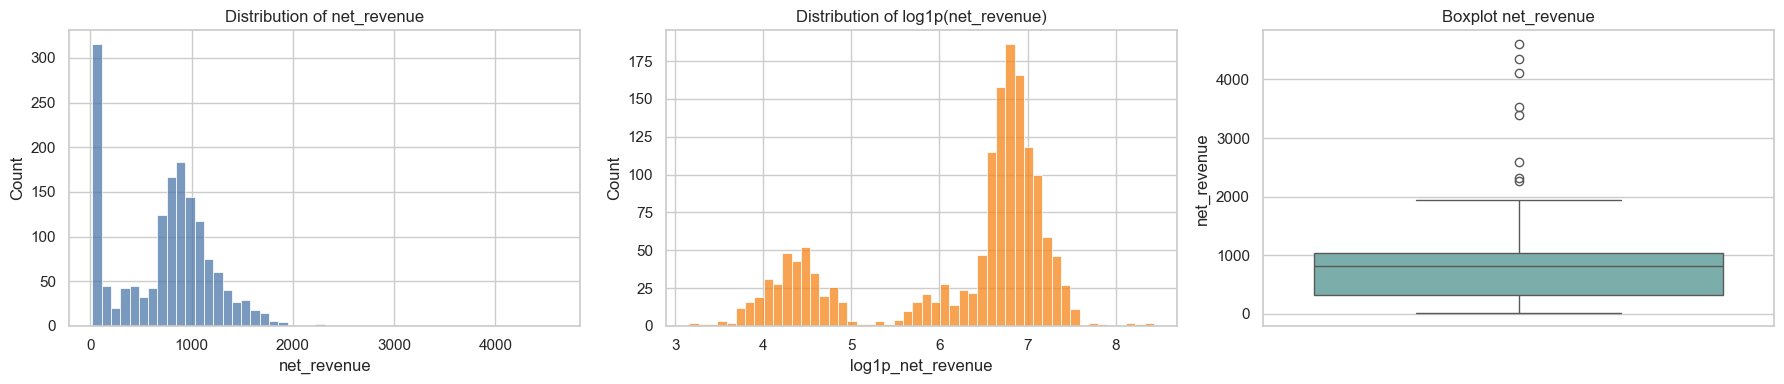

In [12]:
overall_stats = pd.DataFrame({
    "metric": [
        "total_gross_revenue",
        "total_return_value",
        "total_net_revenue",
        "total_quantity_sold",
        "mean_net_revenue_per_store_day",
        "median_net_revenue_per_store_day",
        "max_net_revenue_per_store_day",
        "return_day_pct",
        "return_value_rate_pct",
    ],
    "value": [
        eda_df["gross_revenue"].sum(),
        eda_df["return_value"].sum(),
        eda_df["net_revenue"].sum(),
        eda_df["quantity_sold"].sum(),
        eda_df["net_revenue"].mean(),
        eda_df["net_revenue"].median(),
        eda_df["net_revenue"].max(),
        eda_df["has_returns"].mean() * 100,
        eda_df["return_value"].sum() / eda_df["gross_revenue"].sum() * 100,
    ],
})

display(overall_stats)
display(eda_df[["gross_revenue", "return_value", "net_revenue", "quantity_sold", "line_item_count", "distinct_customers"]].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]))

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
sns.histplot(eda_df["net_revenue"], bins=50, color="#4C78A8", ax=axes[0])
axes[0].set_title("Distribution of net_revenue")
axes[0].set_xlabel("net_revenue")

sns.histplot(eda_df["log1p_net_revenue"], bins=50, color="#F58518", ax=axes[1])
axes[1].set_title("Distribution of log1p(net_revenue)")
axes[1].set_xlabel("log1p_net_revenue")

sns.boxplot(data=eda_df, y="net_revenue", color="#72B7B2", ax=axes[2])
axes[2].set_title("Boxplot net_revenue")
axes[2].set_ylabel("net_revenue")

plt.tight_layout()
plt.show()

## 12. EDA theo store/state/store type

,store_state,stores,rows,total_net_revenue,mean_net_revenue,median_net_revenue,total_return_value,revenue_share_pct
2,WA,7,840,"556,574.5300",662.5887,743.9500,"5,518.6300",47.7100
0,CA,4,480,"327,031.1900",681.3150,796.4400,"3,098.5300",28.0334
1,OR,2,240,"282,972.1800","1,179.0507","1,073.0950","2,761.3800",24.2566


,store_id,store_name,store_city,store_state,store_type,rows,total_net_revenue,mean_net_revenue,median_net_revenue,total_sqft,grocery_sqft,revenue_share_pct
5,13,Store 13,Salem,OR,Deluxe Supermarket,120,"168,827.2900","1,406.8941","1,281.0200",27694,18670,14.4720
9,17,Store 17,Tacoma,WA,Deluxe Supermarket,120,"156,088.5400","1,300.7378","1,255.9850",33858,22123,13.3800
7,15,Store 15,Seattle,WA,Supermarket,120,"114,844.1700",957.0348,899.8600,21215,13305,9.8445
4,11,Store 11,Portland,OR,Supermarket,120,"114,144.8900",951.2074,928.7350,20319,16232,9.7846
12,24,Store 24,San Diego,CA,Supermarket,120,"110,279.5900",918.9966,886.4750,27372,18293,9.4533
3,7,Store 7,Los Angeles,CA,Supermarket,120,"110,256.7000",918.8058,858.2750,23598,14210,9.4513
1,3,Store 3,Bremerton,WA,Supermarket,120,"109,787.8700",914.8989,881.8250,39696,24390,9.4111
8,16,Store 16,Spokane,WA,Supermarket,120,"109,324.0200",911.0335,872.2750,30268,22063,9.3713
2,6,Store 6,Beverly Hills,CA,Gourmet Supermarket,120,"97,169.9600",809.7497,816.3050,23688,15337,8.3295
11,23,Store 23,Yakima,WA,Mid-Size Grocery,120,"47,053.9500",392.1162,384.0150,29182,19283,4.0335


,store_type,stores,total_net_revenue,mean_net_revenue,median_net_revenue,mean_total_sqft,revenue_share_pct
4,Supermarket,6,"668,637.2400",928.6628,888.1900,"27,078.0000",57.3161
0,Deluxe Supermarket,2,"324,915.8300","1,353.8160","1,271.3200","30,776.0000",27.8520
1,Gourmet Supermarket,1,"97,169.9600",809.7497,816.3050,"23,688.0000",8.3295
2,Mid-Size Grocery,1,"47,053.9500",392.1162,384.0150,"29,182.0000",4.0335
3,Small Grocery,3,"28,800.9200",80.0026,77.8100,"28,867.3333",2.4688


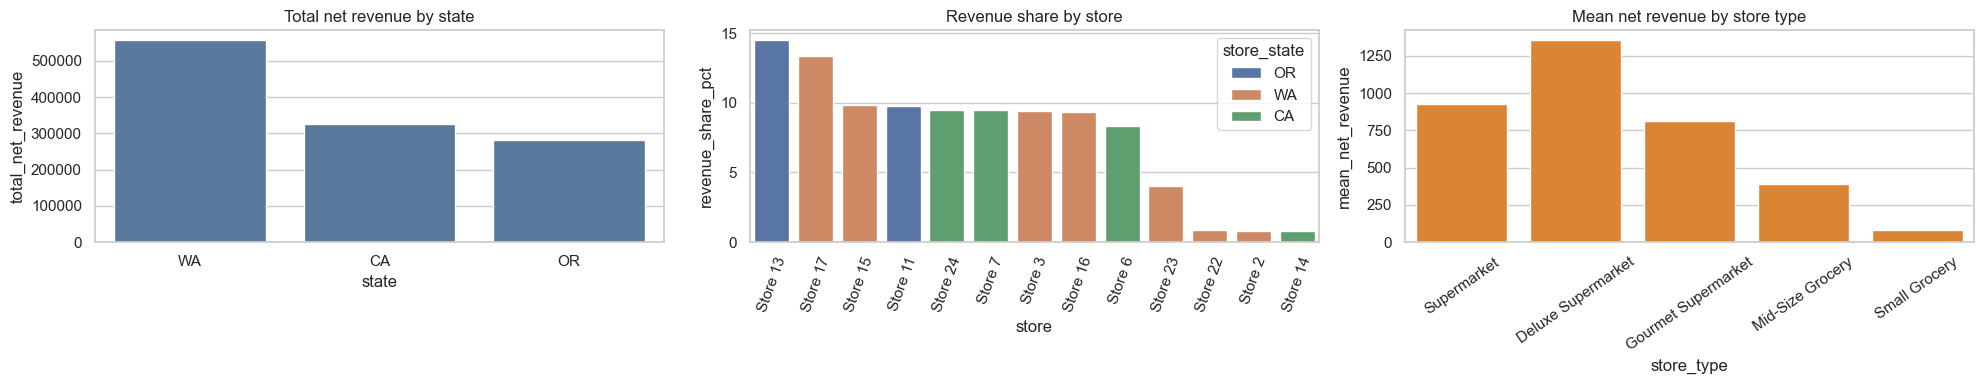

In [13]:
state_summary = (
    eda_df.groupby("store_state", as_index=False)
    .agg(
        stores=("store_id", "nunique"),
        rows=("net_revenue", "size"),
        total_net_revenue=("net_revenue", "sum"),
        mean_net_revenue=("net_revenue", "mean"),
        median_net_revenue=("net_revenue", "median"),
        total_return_value=("return_value", "sum"),
    )
)
state_summary["revenue_share_pct"] = state_summary["total_net_revenue"] / state_summary["total_net_revenue"].sum() * 100
state_summary = state_summary.sort_values("total_net_revenue", ascending=False)

store_summary = (
    eda_df.groupby(["store_id", "store_name", "store_city", "store_state", "store_type"], as_index=False)
    .agg(
        rows=("net_revenue", "size"),
        total_net_revenue=("net_revenue", "sum"),
        mean_net_revenue=("net_revenue", "mean"),
        median_net_revenue=("net_revenue", "median"),
        total_sqft=("total_sqft", "first"),
        grocery_sqft=("grocery_sqft", "first"),
    )
)
store_summary["revenue_share_pct"] = store_summary["total_net_revenue"] / store_summary["total_net_revenue"].sum() * 100
store_summary = store_summary.sort_values("total_net_revenue", ascending=False)

store_type_summary = (
    eda_df.groupby("store_type", as_index=False)
    .agg(
        stores=("store_id", "nunique"),
        total_net_revenue=("net_revenue", "sum"),
        mean_net_revenue=("net_revenue", "mean"),
        median_net_revenue=("net_revenue", "median"),
        mean_total_sqft=("total_sqft", "mean"),
    )
)
store_type_summary["revenue_share_pct"] = store_type_summary["total_net_revenue"] / store_type_summary["total_net_revenue"].sum() * 100
store_type_summary = store_type_summary.sort_values("total_net_revenue", ascending=False)

display(state_summary)
display(store_summary.head(15))
display(store_type_summary)

fig, axes = plt.subplots(1, 3, figsize=(20, 4))
sns.barplot(data=state_summary, x="store_state", y="total_net_revenue", color="#4C78A8", ax=axes[0])
axes[0].set_title("Total net revenue by state")
axes[0].set_xlabel("state")
axes[0].set_ylabel("total_net_revenue")

sns.barplot(data=store_summary, x="store_name", y="revenue_share_pct", hue="store_state", dodge=False, ax=axes[1])
axes[1].set_title("Revenue share by store")
axes[1].set_xlabel("store")
axes[1].set_ylabel("revenue_share_pct")
axes[1].tick_params(axis="x", rotation=70)

sns.barplot(data=store_type_summary, x="store_type", y="mean_net_revenue", color="#F58518", ax=axes[2])
axes[2].set_title("Mean net revenue by store type")
axes[2].set_xlabel("store_type")
axes[2].set_ylabel("mean_net_revenue")
axes[2].tick_params(axis="x", rotation=35)

plt.tight_layout()
plt.show()

## 13. EDA theo thời gian và calendar

,date,total_net_revenue,active_store_days,total_quantity_sold,rolling_28d_net_revenue
count,649,649.0000,649.0000,649.0000,643.0000
mean,1998-01-01 04:50:39.753466,"1,797.5006",2.4037,856.5470,"1,795.5520"
min,1997-01-01 00:00:00,42.6500,1.0000,20.0000,"1,224.3120"
25%,1997-06-30 00:00:00,954.0900,1.0000,461.0000,"1,650.6029"
50%,1998-01-03 00:00:00,"1,585.9000",2.0000,754.0000,"1,773.1825"
75%,1998-07-05 00:00:00,"2,457.8800",3.0000,"1,176.0000","1,905.6616"
max,1998-12-30 00:00:00,"7,884.8900",6.0000,"3,850.0000","2,518.5489"
std,NaN,"1,152.3468",1.1994,549.8455,204.5881


,day_of_week,day_of_week_num,mean_net_revenue,median_net_revenue,rows
1,Monday,0,782.1681,847.8000,229
5,Tuesday,1,687.0920,786.6850,222
6,Wednesday,2,707.2566,797.2700,216
4,Thursday,3,768.7849,832.8200,235
0,Friday,4,753.3147,781.0550,206
2,Saturday,5,769.4805,850.3450,228
3,Sunday,6,762.8158,814.9450,224


,month,mean_net_revenue,median_net_revenue,total_net_revenue
0,1,722.8825,795.4300,"93,974.7200"
1,2,697.6174,809.3150,"90,690.2600"
2,3,773.5887,835.2600,"100,566.5300"
3,4,697.2389,786.5700,"90,641.0600"
4,5,704.1887,730.1650,"91,544.5300"
5,6,717.4422,788.1650,"93,267.4900"
6,7,737.3539,789.1600,"95,856.0100"
7,8,719.7912,880.7350,"93,572.8600"
8,9,718.2291,804.5850,"93,369.7800"
9,10,670.1961,797.1200,"87,125.4900"


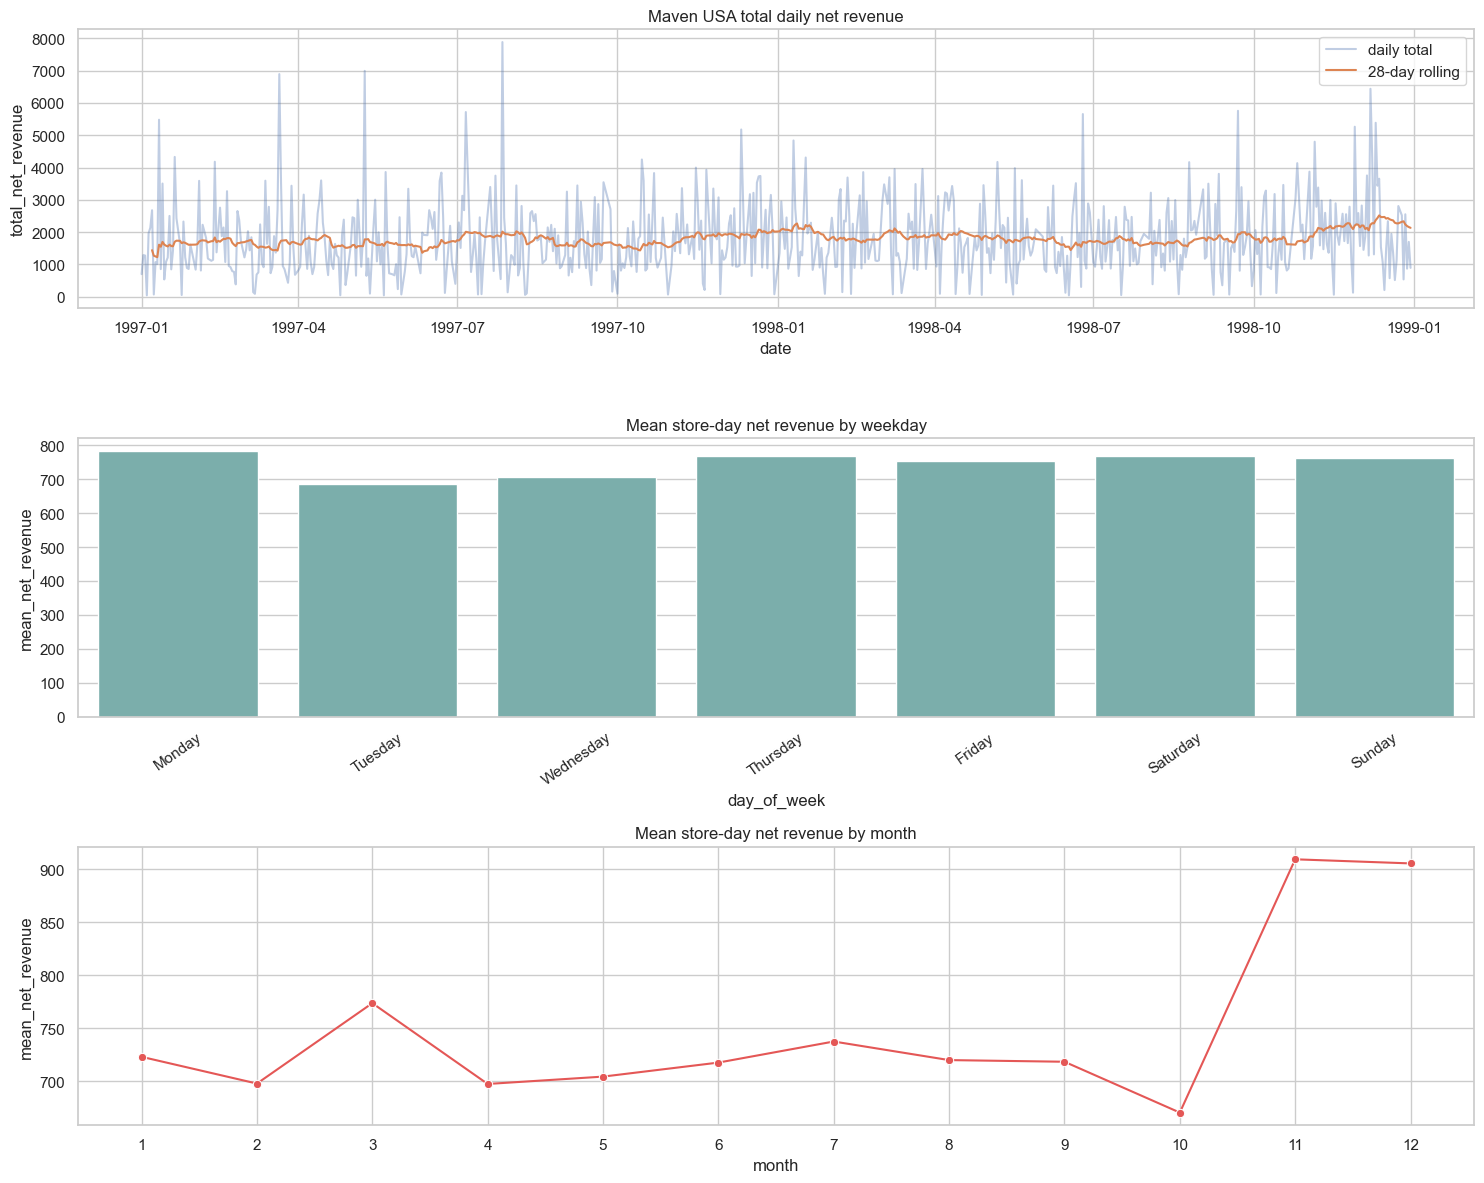

In [14]:
total_daily = (
    eda_df.groupby("date", as_index=False)
    .agg(
        total_net_revenue=("net_revenue", "sum"),
        active_store_days=("store_id", "nunique"),
        total_quantity_sold=("quantity_sold", "sum"),
    )
    .sort_values("date")
)
total_daily["rolling_28d_net_revenue"] = total_daily["total_net_revenue"].rolling(28, min_periods=7).mean()

weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
weekday_summary = (
    eda_df.groupby(["day_of_week", "day_of_week_num"], as_index=False)
    .agg(mean_net_revenue=("net_revenue", "mean"), median_net_revenue=("net_revenue", "median"), rows=("net_revenue", "size"))
    .sort_values("day_of_week_num")
)
month_summary = (
    eda_df.groupby("month", as_index=False)
    .agg(mean_net_revenue=("net_revenue", "mean"), median_net_revenue=("net_revenue", "median"), total_net_revenue=("net_revenue", "sum"))
)

display(total_daily.describe())
display(weekday_summary)
display(month_summary)

fig, axes = plt.subplots(3, 1, figsize=(15, 12))
sns.lineplot(data=total_daily, x="date", y="total_net_revenue", alpha=0.35, ax=axes[0], label="daily total")
sns.lineplot(data=total_daily, x="date", y="rolling_28d_net_revenue", ax=axes[0], label="28-day rolling")
axes[0].set_title("Maven USA total daily net revenue")
axes[0].set_xlabel("date")
axes[0].set_ylabel("total_net_revenue")
axes[0].legend()

sns.barplot(data=weekday_summary, x="day_of_week", y="mean_net_revenue", order=weekday_order, color="#72B7B2", ax=axes[1])
axes[1].set_title("Mean store-day net revenue by weekday")
axes[1].set_xlabel("day_of_week")
axes[1].set_ylabel("mean_net_revenue")
axes[1].tick_params(axis="x", rotation=35)

sns.lineplot(data=month_summary, x="month", y="mean_net_revenue", marker="o", color="#E45756", ax=axes[2])
axes[2].set_title("Mean store-day net revenue by month")
axes[2].set_xlabel("month")
axes[2].set_ylabel("mean_net_revenue")
axes[2].set_xticks(range(1, 13))

plt.tight_layout()
plt.show()

## 14. EDA weather sau join

Phần này kiểm tra weather distribution và tương quan mô tả với `net_revenue`. Đây chưa phải kiểm định nhân quả; weather dễ bị confound bởi store/state/seasonality.

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
temperature_mean_c,"1,560.0000",12.6063,7.2382,-18.1000,-4.5870,1.2000,7.2000,12.8000,17.9000,24.1050,28.1000,32.0000
precipitation_mm,"1,560.0000",2.4228,5.7118,0.0000,0.0000,0.0000,0.0000,0.0000,1.7000,13.3000,27.7350,48.1000
rain_mm,"1,560.0000",2.3228,5.6237,0.0000,0.0000,0.0000,0.0000,0.0000,1.5000,13.1000,27.7350,48.1000
snowfall_cm,"1,560.0000",0.0727,0.5099,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.1400,2.1000,8.0500
wind_speed_max_kmh,"1,560.0000",14.0442,5.3661,3.9000,5.5000,7.1000,10.1000,13.3000,16.7000,23.9000,31.6000,40.0000
shortwave_radiation_mj_m2,"1,560.0000",15.4295,8.8568,0.3300,0.7359,2.2190,7.5450,15.0900,23.2125,29.3700,30.9023,31.7500


,is_rainy_day,rows,mean_net_revenue,median_net_revenue,mean_precipitation_mm
0,0,925,721.5674,804.4800,0.0000
1,1,635,786.0285,860.1300,5.9520


,feature,corr_with_net_revenue
0,net_revenue,1.0000
1,temperature_mean_c,-0.0186
2,precipitation_mm,0.0581
3,rain_mm,0.0614
4,snowfall_cm,-0.0213
5,wind_speed_max_kmh,-0.0010
6,shortwave_radiation_mj_m2,-0.1069


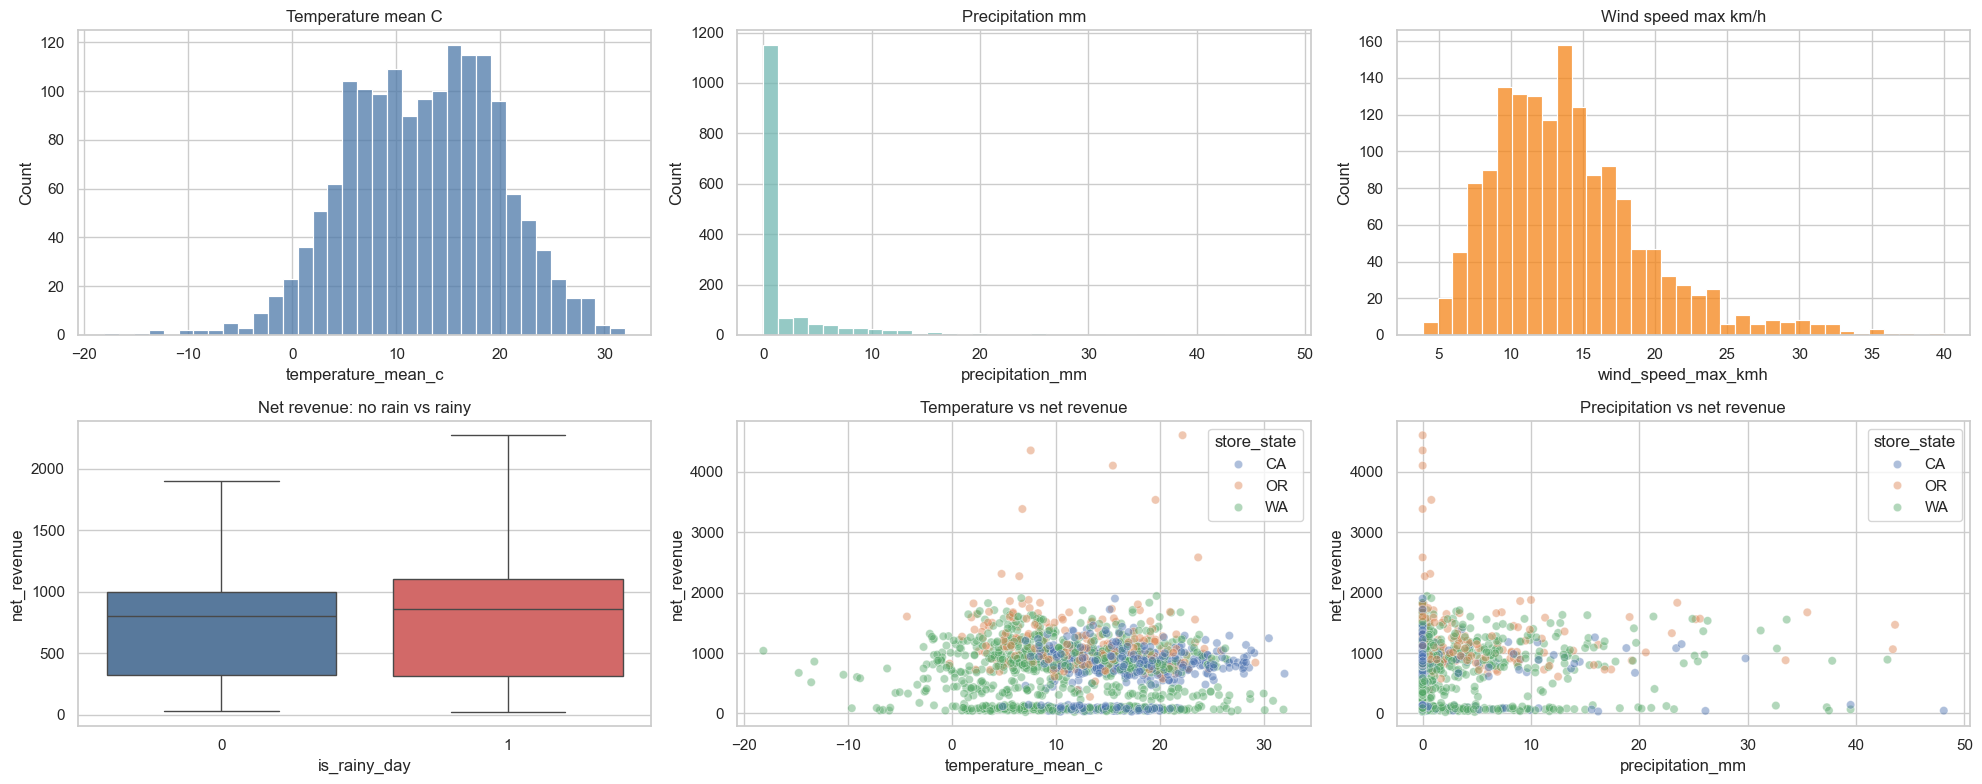

In [15]:
weather_summary = eda_df[
    ["temperature_mean_c", "precipitation_mm", "rain_mm", "snowfall_cm", "wind_speed_max_kmh", "shortwave_radiation_mj_m2"]
].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T

rain_summary = (
    eda_df.groupby("is_rainy_day", as_index=False)
    .agg(
        rows=("net_revenue", "size"),
        mean_net_revenue=("net_revenue", "mean"),
        median_net_revenue=("net_revenue", "median"),
        mean_precipitation_mm=("precipitation_mm", "mean"),
    )
)

weather_corr = (
    eda_df[["net_revenue", "temperature_mean_c", "precipitation_mm", "rain_mm", "snowfall_cm", "wind_speed_max_kmh", "shortwave_radiation_mj_m2"]]
    .corr()[["net_revenue"]]
    .reset_index()
    .rename(columns={"index": "feature", "net_revenue": "corr_with_net_revenue"})
)

display(weather_summary)
display(rain_summary)
display(weather_corr)

fig, axes = plt.subplots(2, 3, figsize=(20, 8))
sns.histplot(eda_df["temperature_mean_c"], bins=35, color="#4C78A8", ax=axes[0, 0])
axes[0, 0].set_title("Temperature mean C")

sns.histplot(eda_df["precipitation_mm"], bins=35, color="#72B7B2", ax=axes[0, 1])
axes[0, 1].set_title("Precipitation mm")

sns.histplot(eda_df["wind_speed_max_kmh"], bins=35, color="#F58518", ax=axes[0, 2])
axes[0, 2].set_title("Wind speed max km/h")

sns.boxplot(data=eda_df, x="is_rainy_day", y="net_revenue", palette=["#4C78A8", "#E45756"], showfliers=False, ax=axes[1, 0])
axes[1, 0].set_title("Net revenue: no rain vs rainy")
axes[1, 0].set_xlabel("is_rainy_day")

sns.scatterplot(data=eda_df, x="temperature_mean_c", y="net_revenue", hue="store_state", alpha=0.45, ax=axes[1, 1])
axes[1, 1].set_title("Temperature vs net revenue")
axes[1, 1].set_xlabel("temperature_mean_c")
axes[1, 1].set_ylabel("net_revenue")

sns.scatterplot(data=eda_df, x="precipitation_mm", y="net_revenue", hue="store_state", alpha=0.45, ax=axes[1, 2])
axes[1, 2].set_title("Precipitation vs net revenue")
axes[1, 2].set_xlabel("precipitation_mm")
axes[1, 2].set_ylabel("net_revenue")

plt.tight_layout()
plt.show()

## 15. Nhận xét nhanh và hướng tiếp theo

Từ notebook này, ta có bảng Maven USA store-day đã join weather sạch ở key `date + store_id`. Các phân tích cơ bản cần đọc theo hướng:

- `net_revenue` là target đã trừ returns, nhưng vẫn là computed revenue vì transaction gốc không có invoice amount.
- Join weather đạt nếu không có duplicate key và không missing weather.
- Weather correlation thô chỉ là mô tả; cần kiểm soát store/state/month/weekday trước khi kết luận weather có ích.
- Với đề tài forecasting, bước tiếp theo nên tạo lag/rolling theo `store_id`, rồi chạy ablation: baseline calendar/store, thêm returns/store attributes, rồi thêm weather để xem weather có giảm lỗi validation không.